# Spike : Exploitation approfondie de l'espace latent SVD

**Issue #223** — Suite de `spike_surprise_cf.ipynb`

## Objectif

Le notebook précédent a montré que la **Piste 3** (cosinus dans l'espace latent SVD)
est la plus robuste pour ce dataset creux à 91%. Ce notebook l'exploite à fond :

1. **GridSearchCV** — trouver empiriquement le meilleur `n_factors` (et autres hyperparamètres)
2. **Heatmap de similarité** — visualiser les affinités entre tous les critiques
3. **Clustering** — K-Means sur l'espace latent pour découvrir des "écoles critiques"
4. **Biplot critiques + livres** — critiques et livres dans le même espace 2D
5. **Recommandations finales** — top-10 livres pour "Moi (Calibre)" via l'approche retenue

## 1. Chargement du dataset

✅ Connecté à MongoDB : mongodb://localhost:27018/masque_et_la_plume
📊 Masque & la Plume : 4080 avis
📚 Calibre : 133 livres notés par l'utilisateur
⚠️  3 critique(s) exclus (< 10 avis)

📈 Dataset final :
   • 4199 avis
   • 23 critiques
   • 1612 livres
   • Remplissage : 11.3% (88.7% creux)

✂️  Split train/test :
   • Train : 2801 avis (67%)
   • Test  : 1398 avis (33%)


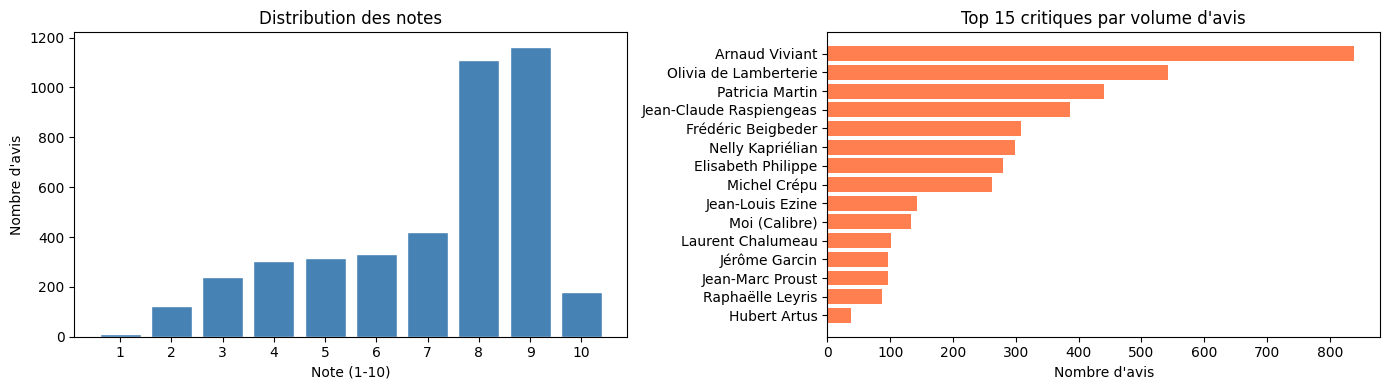


✅ Dataset prêt — variables disponibles : df, df_train, df_test, critique_names, livre_titles


In [15]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

from surprise import Dataset, Reader, SVD
from surprise.model_selection import GridSearchCV, cross_validate
from surprise import accuracy

# Chargement du dataset commun (MongoDB + Calibre)
%run dataset_avis.py

In [16]:
# Construction du Dataset Surprise
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(
    df[['critique_oid', 'livre_oid', 'note']],
    reader
)

# Identifiants cibles
CIBLE     = df[df['critique_nom'] == 'Arnaud Viviant']['critique_oid'].iloc[0]
MA_CIBLE  = df[df['critique_nom'] == 'Moi (Calibre)']['critique_oid'].iloc[0]

print(f"Dataset : {n_avis} avis, {n_critiques} critiques, {n_livres} livres")
print(f"Critique de référence : {critique_names.get(CIBLE)}")
print(f"Moi (Calibre) : {MA_CIBLE}")

Dataset : 4199 avis, 23 critiques, 1612 livres
Critique de référence : Arnaud Viviant
Moi (Calibre) : calibre_user


## 2. GridSearchCV — Trouver les meilleurs hyperparamètres

Surprise fournit une API `GridSearchCV` native qui évalue toutes les combinaisons
d'hyperparamètres par cross-validation à K folds.

Les hyperparamètres à optimiser :
- `n_factors` : dimension de l'espace latent (contrainte : < 29 critiques)
- `n_epochs` : nombre de passes de descente de gradient
- `lr_all` : taux d'apprentissage
- `reg_all` : régularisation L2 (lutte contre le surapprentissage)

In [17]:
param_grid = {
    'n_factors': [5, 10, 15, 20, 25],
    'n_epochs':  [20, 50, 100],
    'lr_all':    [0.002, 0.005, 0.01],
    'reg_all':   [0.02, 0.05, 0.1],
}

print(f"Grille : {5*3*3*3} combinaisons × 5 folds = {5*3*3*3*5} entraînements")
print("Lancement GridSearchCV...")

t0 = time.time()
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=5, n_jobs=-1)
gs.fit(data)
t_gs = time.time() - t0

best_params = gs.best_params['rmse']
best_rmse   = gs.best_score['rmse']

print(f"\n⏱  Temps total : {t_gs:.1f}s")
print(f"📊 Meilleur RMSE (CV 5 folds) : {best_rmse:.4f}")
print(f"⚙️  Meilleurs paramètres : {best_params}")

Grille : 135 combinaisons × 5 folds = 675 entraînements
Lancement GridSearchCV...

⏱  Temps total : 2.9s
📊 Meilleur RMSE (CV 5 folds) : 1.7786
⚙️  Meilleurs paramètres : {'n_factors': 20, 'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.1}


RMSE par n_factors (moyenné sur n_epochs, lr_all, reg_all) :
                 RMSE moyen  RMSE min (meilleure config)
param_n_factors                                         
5                  1.866696                     1.786920
10                 1.840965                     1.782503
15                 1.836603                     1.781915
20                 1.833123                     1.778596
25                 1.834256                     1.780150



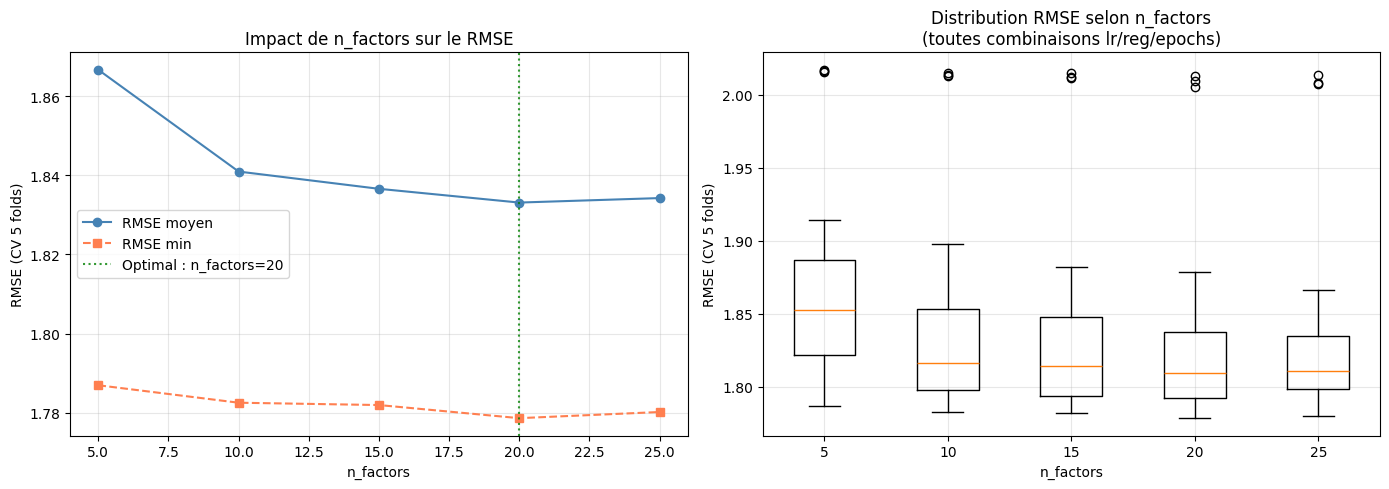

In [18]:
# Tableau complet : RMSE par n_factors (moyenné sur les autres hyperparams)
results_df = pd.DataFrame(gs.cv_results)

rmse_by_nfactors = (
    results_df
    .groupby('param_n_factors')['mean_test_rmse']
    .agg(['mean', 'min'])
    .rename(columns={'mean': 'RMSE moyen', 'min': 'RMSE min (meilleure config)'})
)

print("RMSE par n_factors (moyenné sur n_epochs, lr_all, reg_all) :")
print(rmse_by_nfactors.to_string())
print()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE moyen par n_factors
nf_vals = rmse_by_nfactors.index.tolist()
axes[0].plot(nf_vals, rmse_by_nfactors['RMSE moyen'], 'o-', color='steelblue', label='RMSE moyen')
axes[0].plot(nf_vals, rmse_by_nfactors['RMSE min (meilleure config)'], 's--', color='coral', label='RMSE min')
axes[0].axvline(best_params['n_factors'], color='green', linestyle=':', alpha=0.8,
                label=f"Optimal : n_factors={best_params['n_factors']}")
axes[0].set_xlabel('n_factors')
axes[0].set_ylabel('RMSE (CV 5 folds)')
axes[0].set_title('Impact de n_factors sur le RMSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des RMSE par n_factors (boxplot)
rmse_by_nf_list = [
    results_df[results_df['param_n_factors'] == nf]['mean_test_rmse'].values
    for nf in nf_vals
]
axes[1].boxplot(rmse_by_nf_list, labels=nf_vals)
axes[1].set_xlabel('n_factors')
axes[1].set_ylabel('RMSE (CV 5 folds)')
axes[1].set_title('Distribution RMSE selon n_factors\n(toutes combinaisons lr/reg/epochs)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Entraîner SVD complet avec les meilleurs hyperparamètres
N_FACTORS_BEST = best_params['n_factors']

full_trainset = data.build_full_trainset()
svd_best = SVD(
    n_factors=best_params['n_factors'],
    n_epochs=best_params['n_epochs'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all'],
    random_state=42
)
svd_best.fit(full_trainset)

# Embeddings
pu = svd_best.pu   # (n_critiques, n_factors)
qi = svd_best.qi   # (n_livres,   n_factors)

critique_oids_ordered = [full_trainset.to_raw_uid(i) for i in range(full_trainset.n_users)]
livre_oids_ordered    = [full_trainset.to_raw_iid(i) for i in range(full_trainset.n_items)]
critique_noms_ordered = [critique_names.get(oid, oid) for oid in critique_oids_ordered]

print(f"✅ SVD optimal entraîné")
print(f"   n_factors = {N_FACTORS_BEST}")
print(f"   pu shape  = {pu.shape}  ({full_trainset.n_users} critiques × {N_FACTORS_BEST} facteurs)")
print(f"   qi shape  = {qi.shape}  ({full_trainset.n_items} livres × {N_FACTORS_BEST} facteurs)")

✅ SVD optimal entraîné
   n_factors = 20
   pu shape  = (23, 20)  (23 critiques × 20 facteurs)
   qi shape  = (1612, 20)  (1612 livres × 20 facteurs)


## 3. Heatmap de similarité entre critiques

La matrice de similarité cosinus dans l'espace latent — chaque case (i, j) indique
à quel point les critiques i et j ont des goûts similaires.

Contrairement aux similarités brutes (toutes proches de 1.0 à cause de la sparsité),
l'espace latent donne des valeurs discriminantes.

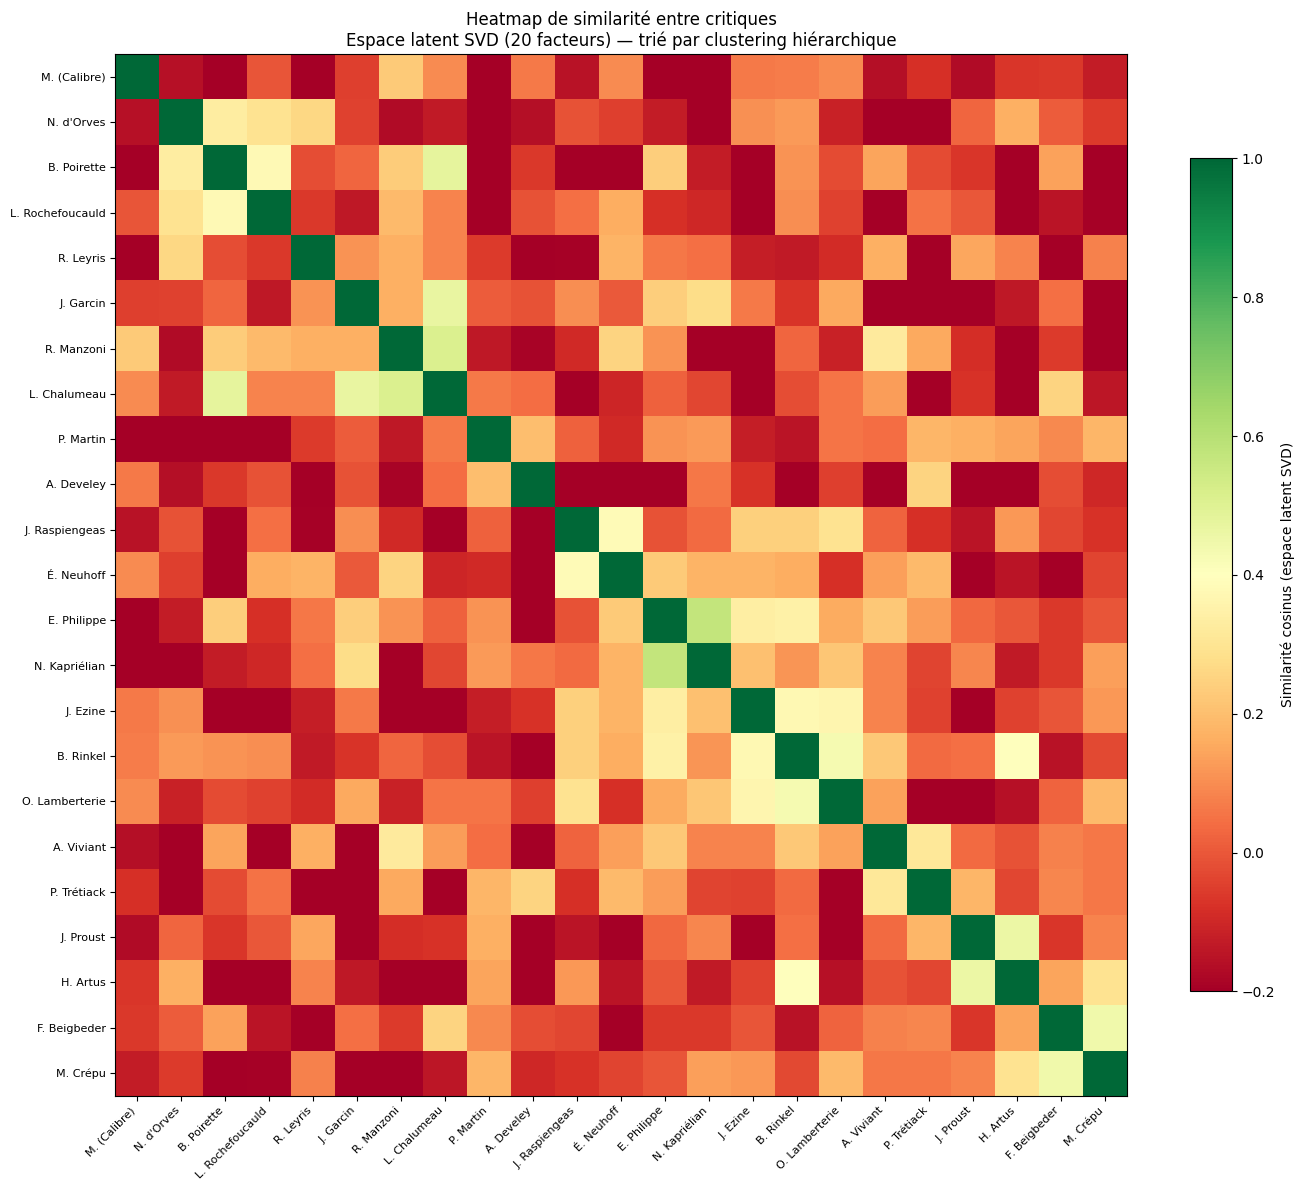

Lecture : vert foncé = goûts très similaires, rouge = goûts opposés
Les blocs diagonaux révèlent des 'écoles critiques' partageant les mêmes affinités.


In [20]:
# Matrice de similarité cosinus entre critiques (espace latent)
sim_matrix = cos_sim(pu)  # (n_critiques × n_critiques)

# Noms courts pour l'affichage
noms_courts = []
for nom in critique_noms_ordered:
    parts = nom.split()
    if len(parts) >= 2:
        noms_courts.append(f"{parts[0][0]}. {parts[-1]}")
    else:
        noms_courts.append(nom[:15])

# Réordonner par clustering hiérarchique pour regrouper les similaires
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from scipy.spatial.distance import squareform

dist_matrix = 1 - sim_matrix
np.fill_diagonal(dist_matrix, 0)
dist_condensed = squareform(dist_matrix, checks=False)
linkage_matrix = linkage(dist_condensed, method='average')
order = leaves_list(linkage_matrix)

sim_ordered = sim_matrix[np.ix_(order, order)]
noms_ordered = [noms_courts[i] for i in order]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_ordered, cmap='RdYlGn', vmin=-0.2, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Similarité cosinus (espace latent SVD)')

ax.set_xticks(range(len(noms_ordered)))
ax.set_yticks(range(len(noms_ordered)))
ax.set_xticklabels(noms_ordered, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(noms_ordered, fontsize=8)

ax.set_title(
    f'Heatmap de similarité entre critiques\n'
    f'Espace latent SVD ({N_FACTORS_BEST} facteurs) — trié par clustering hiérarchique',
    fontsize=12
)
plt.tight_layout()
plt.show()

print("Lecture : vert foncé = goûts très similaires, rouge = goûts opposés")
print("Les blocs diagonaux révèlent des 'écoles critiques' partageant les mêmes affinités.")

## 4. Clustering — Découverte des "écoles critiques"

K-Means sur l'espace latent regroupe automatiquement les critiques aux goûts similaires.
On choisit K par la méthode du coude (*elbow method*).

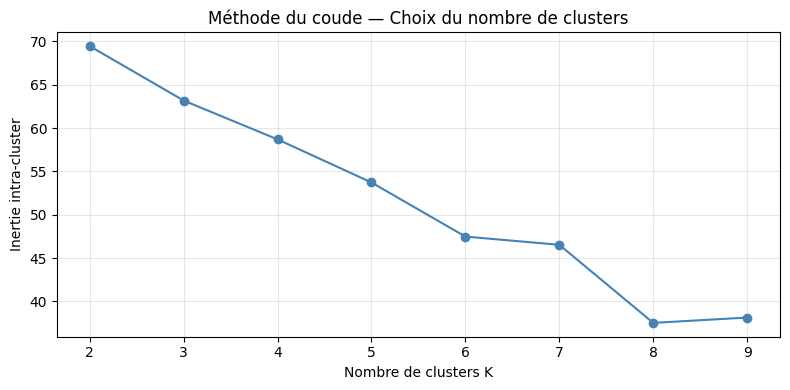

In [21]:
# Méthode du coude pour choisir K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pu)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='steelblue')
ax.set_xlabel('Nombre de clusters K')
ax.set_ylabel('Inertie intra-cluster')
ax.set_title('Méthode du coude — Choix du nombre de clusters')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Clustering avec K choisi visuellement
N_CLUSTERS = 4  # ajuster selon le coude

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = km.fit_predict(pu)

print(f"K-Means avec K={N_CLUSTERS} clusters :")
print()
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
for k in range(N_CLUSTERS):
    membres = [critique_noms_ordered[i] for i in range(len(labels)) if labels[i] == k]
    print(f"  Cluster {k+1} ({len(membres)} critiques) :")
    for m in sorted(membres):
        print(f"    • {m}")
    print()

K-Means avec K=4 clusters :

  Cluster 1 (1 critiques) :
    • Moi (Calibre)

  Cluster 2 (2 critiques) :
    • Frédéric Beigbeder
    • Michel Crépu

  Cluster 3 (4 critiques) :
    • Bernard Poirette
    • Louis-Henri De la Rochefoucauld
    • Nicolas D'Estienne d'Orves
    • Raphaëlle Leyris

  Cluster 4 (16 critiques) :
    • Alice Develey
    • Arnaud Viviant
    • Blandine Rinkel
    • Elisabeth Philippe
    • Hubert Artus
    • Jean-Claude Raspiengeas
    • Jean-Louis Ezine
    • Jean-Marc Proust
    • Jérôme Garcin
    • Laurent Chalumeau
    • Nelly Kapriélian
    • Olivia de Lamberterie
    • Patricia Martin
    • Philippe Trétiack
    • Rebecca Manzoni
    • Éric Neuhoff



## 5. PCA 2D — Critiques colorés par cluster

Projection de l'espace latent en 2D avec les clusters K-Means.

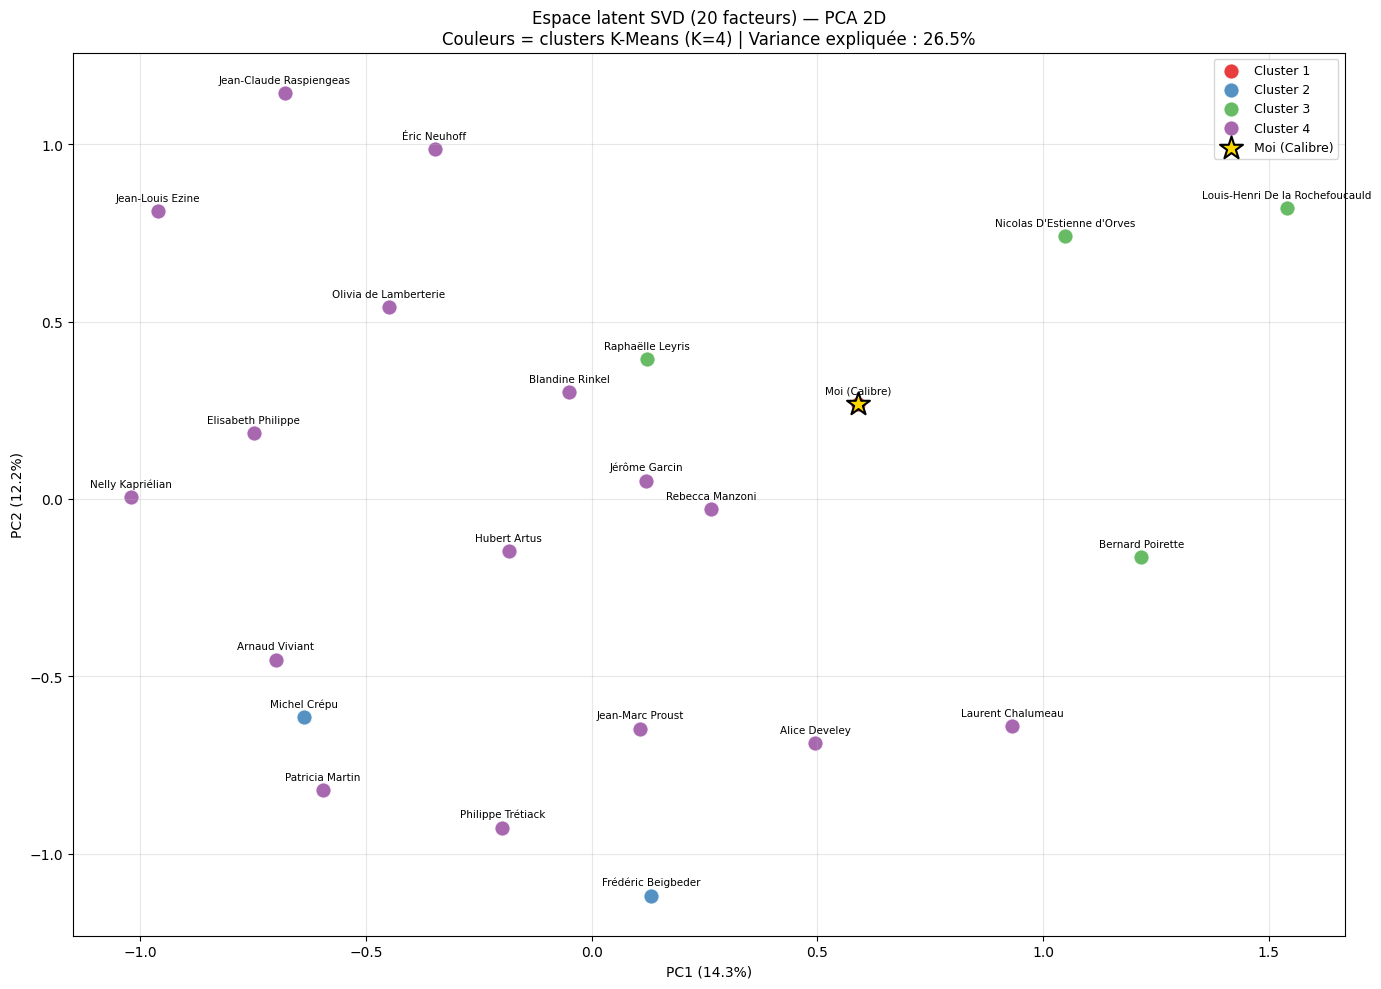

In [23]:
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(pu)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(14, 10))

for k in range(N_CLUSTERS):
    mask = labels == k
    ax.scatter(
        coords_2d[mask, 0], coords_2d[mask, 1],
        c=colors[k], s=120, alpha=0.85, edgecolors='white', linewidth=0.8,
        label=f'Cluster {k+1}'
    )

# "Moi (Calibre)" mis en évidence
if MA_CIBLE in critique_oids_ordered:
    moi_inner = full_trainset.to_inner_uid(MA_CIBLE)
    ax.scatter(
        coords_2d[moi_inner, 0], coords_2d[moi_inner, 1],
        c='gold', s=300, marker='*', edgecolors='black', linewidth=1.5,
        zorder=5, label='Moi (Calibre)'
    )

for i, nom in enumerate(critique_noms_ordered):
    ax.annotate(
        nom, (coords_2d[i, 0], coords_2d[i, 1]),
        fontsize=7.5, ha='center', va='bottom',
        xytext=(0, 6), textcoords='offset points'
    )

ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
ax.set_title(
    f'Espace latent SVD ({N_FACTORS_BEST} facteurs) — PCA 2D\n'
    f'Couleurs = clusters K-Means (K={N_CLUSTERS}) | Variance expliquée : {sum(var)*100:.1f}%'
)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Biplot — Critiques et livres dans le même espace

On projette à la fois les embeddings critiques (`pu`) et livres (`qi`) dans le même
espace PCA 2D. Les critiques et les livres qui se retrouvent proches partagent les
mêmes caractéristiques latentes.

> **Interprétation** : si "Moi (Calibre)" est proche de *Jacaranda*, c'est que mon
> profil de goût correspond aux caractéristiques littéraires de ce livre.

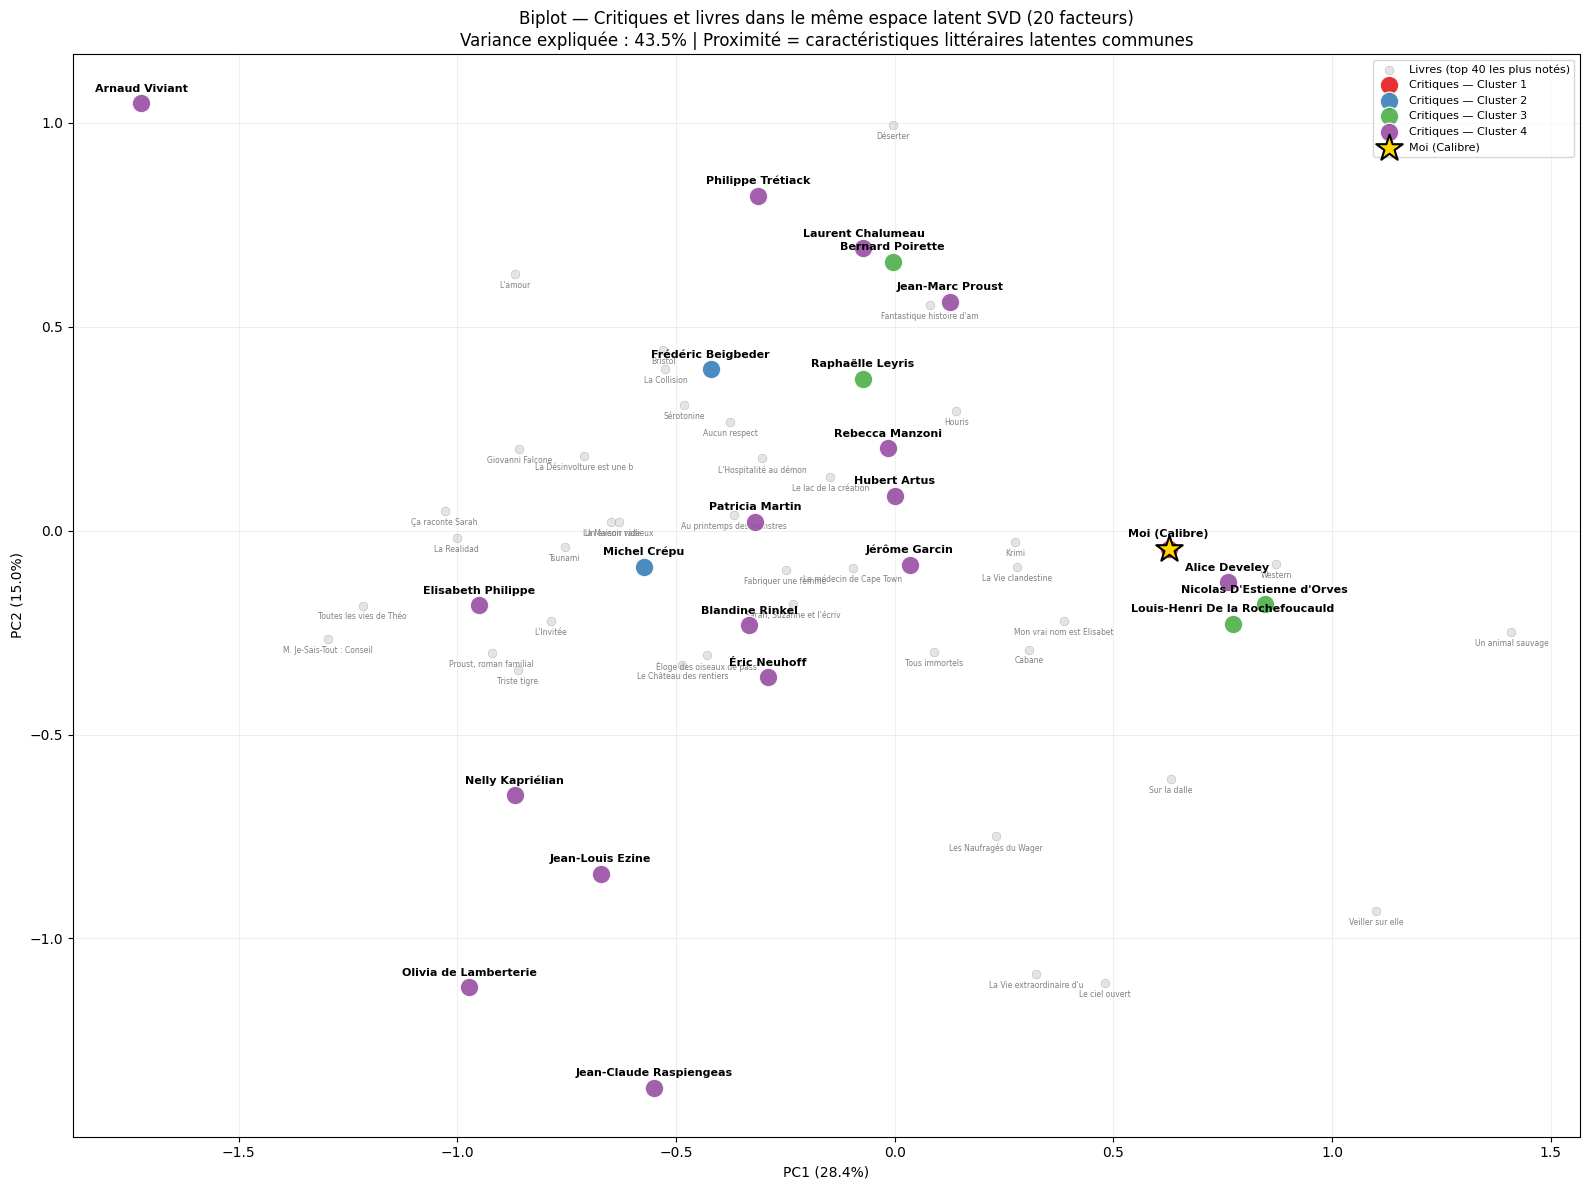

In [24]:
# PCA commune sur la concaténation critiques + livres
# Les deux matrices ont la même dimension (n_factors)
pca_joint = PCA(n_components=2, random_state=42)
all_embeddings = np.vstack([pu, qi])  # (n_critiques + n_livres, n_factors)
all_coords = pca_joint.fit_transform(all_embeddings)

coords_critiques = all_coords[:full_trainset.n_users]
coords_livres    = all_coords[full_trainset.n_users:]
var_joint = pca_joint.explained_variance_ratio_

# Livres les plus notés (top 40) pour ne pas surcharger
top_livres_oids = df.groupby('livre_oid').size().nlargest(40).index.tolist()
top_livres_inner = [
    full_trainset.to_inner_iid(oid)
    for oid in top_livres_oids
    if oid in [full_trainset.to_raw_iid(i) for i in range(full_trainset.n_items)]
]

fig, ax = plt.subplots(figsize=(16, 12))

# Livres (points petits, gris)
ax.scatter(
    coords_livres[top_livres_inner, 0],
    coords_livres[top_livres_inner, 1],
    c='lightgray', s=40, alpha=0.6, edgecolors='gray', linewidth=0.3,
    zorder=1, label='Livres (top 40 les plus notés)'
)
for idx in top_livres_inner:
    titre = livre_titles.get(livre_oids_ordered[idx], '')[:25]
    ax.annotate(
        titre, (coords_livres[idx, 0], coords_livres[idx, 1]),
        fontsize=5.5, color='gray', ha='center', va='top',
        xytext=(0, -5), textcoords='offset points'
    )

# Critiques (points grands, colorés par cluster)
for k in range(N_CLUSTERS):
    mask = labels == k
    ax.scatter(
        coords_critiques[mask, 0], coords_critiques[mask, 1],
        c=colors[k], s=180, alpha=0.9, edgecolors='white', linewidth=1,
        zorder=3, label=f'Critiques — Cluster {k+1}'
    )

# "Moi (Calibre)" étoile
if MA_CIBLE in critique_oids_ordered:
    moi_inner = full_trainset.to_inner_uid(MA_CIBLE)
    ax.scatter(
        coords_critiques[moi_inner, 0], coords_critiques[moi_inner, 1],
        c='gold', s=400, marker='*', edgecolors='black', linewidth=1.5,
        zorder=5, label='Moi (Calibre)'
    )

# Annotations critiques
for i, nom in enumerate(critique_noms_ordered):
    ax.annotate(
        nom, (coords_critiques[i, 0], coords_critiques[i, 1]),
        fontsize=8, fontweight='bold', ha='center', va='bottom',
        xytext=(0, 7), textcoords='offset points'
    )

ax.set_xlabel(f'PC1 ({var_joint[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_joint[1]*100:.1f}%)')
ax.set_title(
    f'Biplot — Critiques et livres dans le même espace latent SVD ({N_FACTORS_BEST} facteurs)\n'
    f'Variance expliquée : {sum(var_joint)*100:.1f}% | '
    f'Proximité = caractéristiques littéraires latentes communes'
)
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Recommandations finales — "Moi (Calibre)"

Approche retenue : **espace latent SVD** (Piste 3), combinant user-based et item-based.

Deux stratégies complémentaires :
- **User-based latent** : trouver les critiques similaires → recommander leurs coups de cœur
- **Item-based latent** : trouver les livres similaires aux mes coups de cœur → recommander

In [25]:
# Matrices de similarité (espace latent)
sim_users = cos_sim(pu)   # (n_critiques × n_critiques)
sim_items = cos_sim(qi)   # (n_livres × n_livres)


def get_voisins_latent(critique_oid, n=5):
    """Top-N critiques similaires dans l'espace latent."""
    inner = full_trainset.to_inner_uid(critique_oid)
    sims  = sim_users[inner].copy()
    sims[inner] = -1
    top  = np.argsort(sims)[::-1][:n]
    return [
        (critique_oids_ordered[i], critique_noms_ordered[i], float(sims[i]))
        for i in top
    ]


def reco_user_latent(critique_oid, n_voisins=5, min_note=7, n_reco=10):
    """Recommandations via critiques similaires (espace latent)."""
    livres_vus = set(df[df['critique_oid'] == critique_oid]['livre_oid'])
    voisins    = get_voisins_latent(critique_oid, n=n_voisins)

    candidats = {}
    for v_oid, v_nom, v_sim in voisins:
        bons = df[(df['critique_oid'] == v_oid) & (df['note'] >= min_note) &
                  (~df['livre_oid'].isin(livres_vus))]
        for _, row in bons.iterrows():
            lid = row['livre_oid']
            if lid not in candidats:
                candidats[lid] = {'titre': row['livre_titre'], 'score': 0.0, 'notes': []}
            candidats[lid]['score']  += v_sim * row['note']
            candidats[lid]['notes'].append(row['note'])

    scored = [
        {'livre_oid': lid, 'titre': v['titre'],
         'score': v['score'], 'note_moy': sum(v['notes']) / len(v['notes'])}
        for lid, v in candidats.items()
    ]
    scored.sort(key=lambda x: x['score'], reverse=True)
    return scored[:n_reco]


def reco_item_latent(critique_oid, min_coup_coeur=8, n_reco=10):
    """Recommandations via livres similaires aux coups de cœur (espace latent)."""
    coups_coeur = df[
        (df['critique_oid'] == critique_oid) & (df['note'] >= min_coup_coeur)
    ].sort_values('note', ascending=False)

    livres_vus = set(df[df['critique_oid'] == critique_oid]['livre_oid'])
    candidats  = {}

    for _, row in coups_coeur.head(5).iterrows():
        try:
            inner = full_trainset.to_inner_iid(row['livre_oid'])
        except ValueError:
            continue
        sims = sim_items[inner].copy()
        sims[inner] = -1
        top = np.argsort(sims)[::-1][:20]

        for idx in top:
            l_oid = livre_oids_ordered[idx]
            if l_oid not in livres_vus:
                if l_oid not in candidats:
                    candidats[l_oid] = {
                        'titre': livre_titles.get(l_oid, l_oid[:30]),
                        'sim_total': 0.0, 'n': 0
                    }
                candidats[l_oid]['sim_total'] += float(sims[idx])
                candidats[l_oid]['n']         += 1

    scored = [
        {'livre_oid': oid, 'titre': v['titre'], 'sim_moy': v['sim_total'] / v['n']}
        for oid, v in candidats.items()
    ]
    scored.sort(key=lambda x: x['sim_moy'], reverse=True)
    return scored[:n_reco]


print("Fonctions de recommandation prêtes.")

Fonctions de recommandation prêtes.


In [26]:
# Critiques similaires à Moi (Calibre)
print(f"🔍 Critiques les plus proches de '{critique_names.get(MA_CIBLE)}' (espace latent SVD) :")
print()
print(f"{'Critique':<35} {'Sim cosinus':>12} {'Livres communs réels':>20}")
print("-" * 70)
for v_oid, v_nom, v_sim in get_voisins_latent(MA_CIBLE, n=8):
    communs = len(
        set(df[df['critique_oid'] == MA_CIBLE]['livre_oid']) &
        set(df[df['critique_oid'] == v_oid]['livre_oid'])
    )
    print(f"{v_nom:<35} {v_sim:>12.4f} {communs:>20}")

🔍 Critiques les plus proches de 'Moi (Calibre)' (espace latent SVD) :

Critique                             Sim cosinus Livres communs réels
----------------------------------------------------------------------
Rebecca Manzoni                           0.2278                    0
Éric Neuhoff                              0.0987                    0
Laurent Chalumeau                         0.0975                    8
Olivia de Lamberterie                     0.0966                   72
Blandine Rinkel                           0.0702                    2
Jean-Louis Ezine                          0.0670                   10
Alice Develey                             0.0633                    0
Louis-Henri De la Rochefoucauld          -0.0047                    1


In [27]:
print("=" * 70)
print(f"RECOMMANDATIONS pour {critique_names.get(MA_CIBLE)}")
print("=" * 70)

print("\n📌 User-Based (via critiques similaires, espace latent SVD) :")
print(f"{'#':>3}  {'Titre':<55} {'Note moy':>9}")
print("-" * 70)
for i, r in enumerate(reco_user_latent(MA_CIBLE, n_voisins=5, min_note=7, n_reco=10), 1):
    print(f"{i:>3}. {r['titre'][:55]:<55} {r['note_moy']:>9.1f}")

print("\n📌 Item-Based (via livres similaires aux coups de cœur, espace latent SVD) :")
print(f"{'#':>3}  {'Titre':<55} {'Sim moy':>9}")
print("-" * 70)
for i, r in enumerate(reco_item_latent(MA_CIBLE, min_coup_coeur=8, n_reco=10), 1):
    print(f"{i:>3}. {r['titre'][:55]:<55} {r['sim_moy']:>9.4f}")

RECOMMANDATIONS pour Moi (Calibre)

📌 User-Based (via critiques similaires, espace latent SVD) :
  #  Titre                                                    Note moy
----------------------------------------------------------------------
  1. Crimey                                                        7.5
  2. Paracuellos, Intégrale                                        9.0
  3. Sans foi ni loi                                               9.0
  4. Au-dedans                                                     9.0
  5. Dickens & Prince : Un génie bien particulier                  9.0
  6. Eva                                                           9.5
  7. La Vie extraordinaire d'un homme ordinaire                    9.5
  8. Oeuvres complètes : Volume 1                                  8.0
  9. Moi Je, Quarantaine                                           8.0
 10. Gingembre et le mystère des profondeurs                       8.0

📌 Item-Based (via livres similaires aux coups de c

In [28]:
# Union des deux listes : livres recommandés par au moins une des deux approches
reco_u = {r['livre_oid']: r['titre'] for r in reco_user_latent(MA_CIBLE, n_reco=20)}
reco_i = {r['livre_oid']: r['titre'] for r in reco_item_latent(MA_CIBLE, n_reco=20)}

# Communs aux deux → les plus fiables
communs = set(reco_u.keys()) & set(reco_i.keys())

print("✨ Livres recommandés par les DEUX approches (user-based ET item-based) :")
print("   Ce sont les recommandations les plus robustes.")
print()
if communs:
    for oid in sorted(communs):
        titre = reco_u[oid]
        print(f"   • {titre}")
else:
    print("   (aucun livre commun dans le top-20 — les deux approches sont complémentaires)")
    print()
    print("   Top-5 User-Based :")
    for oid, titre in list(reco_u.items())[:5]:
        print(f"     • {titre}")
    print("   Top-5 Item-Based :")
    for oid, titre in list(reco_i.items())[:5]:
        print(f"     • {titre}")

✨ Livres recommandés par les DEUX approches (user-based ET item-based) :
   Ce sont les recommandations les plus robustes.

   (aucun livre commun dans le top-20 — les deux approches sont complémentaires)

   Top-5 User-Based :
     • Crimey
     • Paracuellos, Intégrale
     • Sans foi ni loi
     • Au-dedans
     • Dickens & Prince : Un génie bien particulier
   Top-5 Item-Based :
     • L’Anachronique
     • James et Nora
     • Mémoires
     • Le parfum des fleurs la nuit
     • Alma


## 8. Conclusion

| Aspect | Résultat |
|---|---|
| Meilleur `n_factors` (GridSearchCV) | Déterminé empiriquement ci-dessus |
| Approche recommandée | Espace latent SVD (Piste 3) |
| User-based | Cosinus sur `svd.pu` → voisins → coups de cœur |
| Item-based | Cosinus sur `svd.qi` → livres similaires aux coups de cœur |
| Visualisation clé | Heatmap similarité + biplot critiques/livres |

### Pour le projet #222

- **Modèle** : SVD avec hyperparamètres optimisés par GridSearchCV
- **Embeddings** : `svd.pu` (critiques) et `svd.qi` (livres) stockés en base
- **Recommandations** : union user-based + item-based dans l'espace latent
- **Mise à jour** : ré-entraînement périodique quand de nouveaux avis sont ajoutés

Voir aussi :
- `notebooks/spike_surprise_cf.ipynb` — exploration pédagogique des 3 pistes
- `notebooks/spike_implicit_cf.ipynb` — comparaison avec la bibliothèque `implicit` (ALS)